The first 5 columns:   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Number of rows & columns:(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
datatypes:None
<class 'pandas.DataFrame'>
RangeIndex: 13

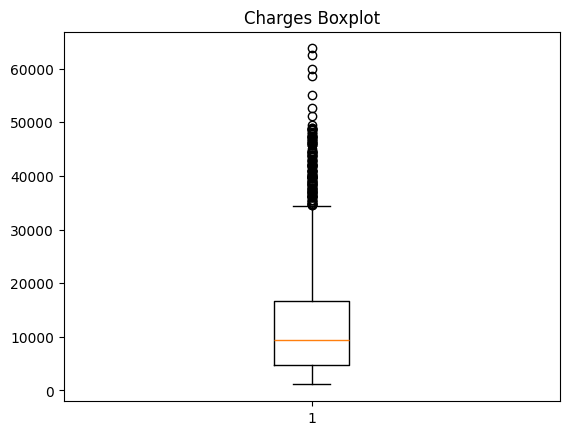

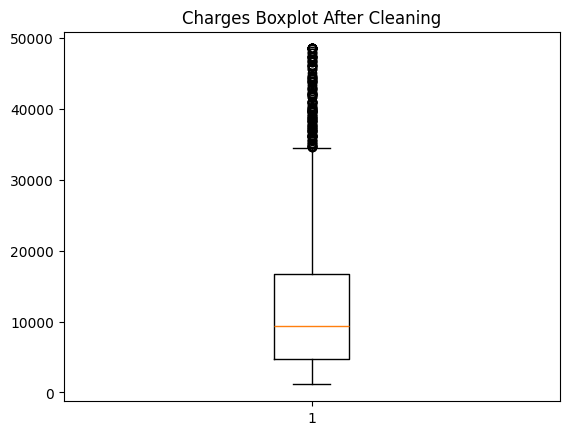

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 columns]


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# Cleaning the Dataset for this phase.
def clean_dataset(df): 

    data = pd.read_csv(df)

    print(f"The first 5 columns:{data.head()}")
    
    print(f"Number of rows & columns:{data.shape}")

    print(f"datatypes:{data.info()}")

    data["sex"] = data["sex"].astype("category")
    data["smoker"] = data["smoker"].astype("category")
    data["region"] = data["region"].astype("category")

    print(f"datatypes:{data.info()}")

    datamiss = data.isnull() 
    print(f"Missing values:{datamiss.sum}")

    datadupli = data.duplicated()
    print(f"Duplicates:{datadupli.sum()}")
    
    data = data.drop_duplicates()
    datadupli = data.duplicated()
    print(f"Duplicates after removal:{datadupli.sum()}")

    plt.boxplot(data["charges"])
    plt.title("Charges Boxplot")
    plt.show()

    VALUE = data["charges"].quantile(0.99)

    data["charges"] = data["charges"].clip(upper=VALUE)

    plt.boxplot(data["charges"])
    plt.title("Charges Boxplot After Cleaning")
    plt.show()

    return data

Insu = clean_dataset("MedicalCost/insurance.csv")

print(Insu)


In [12]:
# Hot encoding the following columns.
pd.get_dummies(Insu,columns=["sex", "region", "smoker"])

,age,bmi,children,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,True,False,False,False,False,True,False,True
1,18,33.770,1,1725.55230,False,True,False,False,True,False,True,False
2,28,33.000,3,4449.46200,False,True,False,False,True,False,True,False
3,33,22.705,0,21984.47061,False,True,False,True,False,False,True,False
4,32,28.880,0,3866.85520,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,False,True,False,False,True,False
1334,18,31.920,0,2205.98080,True,False,True,False,False,False,True,False
1335,18,36.850,0,1629.83350,True,False,False,False,True,False,True,False
1336,21,25.800,0,2007.94500,True,False,False,False,False,True,True,False


In [13]:
# Ordinal encoding smoker column.
Insu["smoker"] = Insu["smoker"].map({"yes" : 1, "no" : 0}).astype(int)

In [14]:
# Defining and setting StandardScaler to a variable.
stan = StandardScaler()

# Scaling the Numerical Columns below.
Insu[["age", "bmi"]] = stan.fit_transform(Insu[["age", "bmi"]])

In [15]:
# Adding 2 domain features:

# Represents medical cost relative to family size by dividing charges by number of children (+1 to avoid division by zero).
Insu["charges_per_child"] = Insu["charges"] / (Insu["children"] + 1)

# Combines BMI and smoking status to represent lifestyle-related health risk.
Insu["risk_score"] = Insu["smoker"] * Insu["bmi"]

# Adding an interaction feature.
Insu["age_bmi_interaction"] = Insu["age"] * Insu["bmi"]

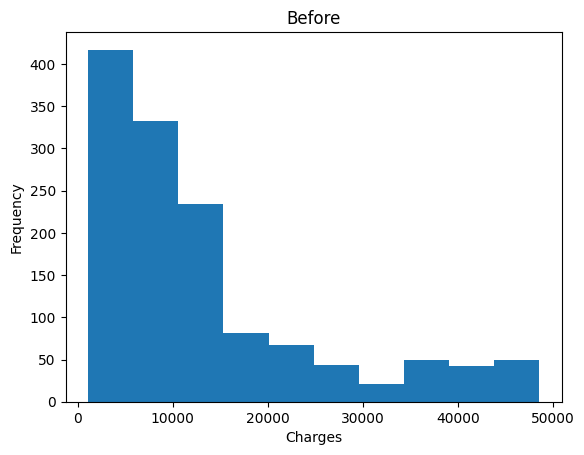

In [16]:
# Using log tranformation on the Charges column:

# Visualizing it as a histogram before using log transformation.
plt.hist(Insu['charges'])
plt.title("Before")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

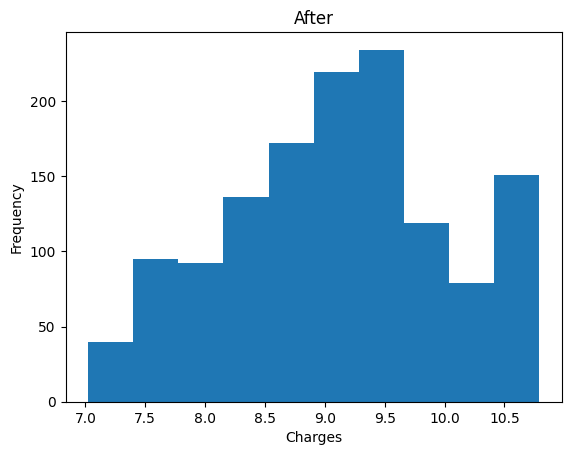

In [17]:
# Visualizing it as a histogram after using log transformation.
plt.hist(np.log1p(Insu["charges"]))
plt.title("After")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [18]:
# Binning the Age column into three groups that represent age groups.
Insu["age_groups"] = pd.cut(Insu["age"], 3, labels=["Young", "Middle aged", "Elders"])

In [19]:
# Checking for redundacy.
Insu.corr(numeric_only=True)
# No feature pairs had correlation above 0.95, so no redundant features were removed.

,age,bmi,children,smoker,charges,charges_per_child,risk_score,age_bmi_interaction
age,1.000000,0.109344,0.041536,-0.025587,0.300596,0.257301,0.026579,0.033229
bmi,0.109344,1.000000,0.012755,0.003746,0.196643,0.145810,0.468222,-0.049466
children,0.041536,0.012755,1.000000,0.007331,0.069540,-0.362354,-0.005428,0.014149
smoker,-0.025587,0.003746,0.007331,1.000000,0.790154,0.647297,0.006361,-0.024644
charges,0.300596,0.196643,0.069540,0.790154,1.000000,0.790436,0.347691,-0.017980
charges_per_child,0.257301,0.145810,-0.362354,0.647297,0.790436,1.000000,0.262222,-0.027647
risk_score,0.026579,0.468222,-0.005428,0.006361,0.347691,0.262222,1.000000,-0.058862
age_bmi_interaction,0.033229,-0.049466,0.014149,-0.024644,-0.017980,-0.027647,-0.058862,1.000000


In [20]:
# Saving an updated version of the dataset to use it for the next phases.
Insu.to_csv('updated_insurance.csv', index=False)